In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


In [32]:
num_epochs = 100
in_dim = 784
hidden_dim = 256
latent_dim = 8
batch_size = 100

In [33]:
class VanillaAutoEncoder(nn.Module):
        def __init__(self, in_dim, hidden_dim, latent_dim):
                super().__init__()
                self.encoder = nn.Sequential(
                        nn.Linear(in_dim, hidden_dim),
                        nn.ReLU(),
                        nn.Linear(hidden_dim, latent_dim),
                )
                self.decoder = nn.Sequential(
                        nn.Linear(latent_dim, hidden_dim),
                        nn.ReLU(),
                        nn.Linear(hidden_dim, in_dim),
                        nn.Sigmoid()
                )

        def forward(self,x):
                latent = self.encoder(x)
                output = self.decoder(latent)
                return output, latent


In [34]:
class VAE(nn.Module):
        def __init__(self, in_dim, hidden_dim, latent_dim):
                super().__init__()
      
                self.encoder = nn.Sequential(
                        nn.Linear(in_dim, hidden_dim),
                        nn.ReLU(),
                        
                )
                self.mu_layer = nn.Linear(hidden_dim, latent_dim)
                self.logvar_layer = nn.Linear(hidden_dim, latent_dim)

                self.decoder = nn.Sequential(
                        nn.Linear(latent_dim, hidden_dim),
                        nn.ReLU(),
                        nn.Linear(hidden_dim, in_dim),
                        nn.Sigmoid()
                )

        def encode(self, x):
                hidden = self.encoder(x)
                mu = self.mu_layer(hidden)
                logvar = self.logvar_layer(hidden)
                return mu, logvar

        def reparameterize(self, mu, logvar):
                std = torch.exp(0.5 * logvar)   # because logvar = log(sigma^2)
                eps = torch.randn_like(std)
                z = mu + std * eps
                return z


        def forward(self,x):
                mu, logvar = self.encode(x)
                z = self.reparameterize(mu, logvar)
                output = self.decoder(z)
                return output, mu, logvar, z #output, mu, logvar, and latent

In [35]:
def test(device, model, optimizer, name, dps):

        losses = []
        kl_loss = []
        transform = transforms.ToTensor()

        mnist_train = datasets.MNIST(
                root="./data",
                train=True,
                download=True,
                transform=transform
        )

        mnist_test = datasets.MNIST(
                root="./data",
                train=False,
                download=True,
                transform=transform
        )

        train_subset = Subset(mnist_train, range(dps))
        test_subset = Subset(mnist_test, range(dps))

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

        #------
        losses = []
        if name == "VAE":
                for epoch in range(0,num_epochs):
                        epoch_loss = 0.0
                        epoch_kl_loss = 0.0
                        for x, y in tqdm(train_loader):
                                x = x.to(device)
                                x = x.view(x.size(0), -1)
                                optimizer.zero_grad()
                                x_hat, mu, logvars, latent = model(x)
                                KL_loss = (-0.5) * torch.sum(1+logvars - mu.pow(2) - logvars.exp()) / x.size(0)
                                Recon_loss = F.binary_cross_entropy(x_hat, x, reduction = "sum") / x.size(0)
                                loss = KL_loss + Recon_loss
                                loss.backward()
                                optimizer.step()
                                epoch_loss += loss.item()
                                epoch_kl_loss += KL_loss.item()
                        avg_loss = epoch_loss/len(train_loader)
                        avg_kl_loss = epoch_kl_loss / len(train_loader)
                        kl_loss.append(avg_kl_loss)
                        losses.append(avg_loss)
        else:
                for epoch in range(0,num_epochs):
                        epoch_loss = 0.0
                        for x, y in tqdm(train_loader):
                                x = x.to(device)
                                x = x.view(x.size(0), -1)
                                optimizer.zero_grad()
                                x_hat, latent = model(x)


                                loss = F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)
                                loss.backward()
                                optimizer.step()

                                epoch_loss += loss.item()
                        avg_loss = epoch_loss/len(train_loader)

                        losses.append(avg_loss)

        #------
        plt.plot(losses)
        plt.xlabel("Epoch")
        plt.ylabel("MSE reconstruction loss")
        plt.title("Autoencoder training loss")
        plt.show()

        plt.plot(kl_loss)
        plt.xlabel("Epoch")
        plt.ylabel("KL loss")
        plt.title("Autoencoder training loss")
        plt.show()



        def extract_latents(model, loader, device):
                model.eval()

                all_z = []
                all_y = []

                with torch.no_grad():
                        for x, y in loader:
                                x = x.to(device)
                                x = x.view(x.size(0), -1)
                                x_hat = None
                                z = None
                                if name == "VAE":
                                        x_hat, z,_,_ = model(x)
                                else:
                                        x_hat, z = model(x)
                                all_z.append(z.cpu())
                                all_y.append(y)

                all_z = torch.cat(all_z, dim=0).numpy()
                all_y = torch.cat(all_y, dim=0).numpy()

                return all_z, all_y

        z_train, y_train = extract_latents(model, train_loader, device)
        z_test, y_test = extract_latents(model, test_loader, device)

        print(z_train.shape, y_train.shape)
        print(z_test.shape, y_test.shape)


        pca = PCA(n_components=2)

        train_2d = PCA(n_components=2).fit_transform(z_train)
        test_2d = PCA(n_components=2).fit_transform(z_test)


        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(
        train_2d[:, 0],
        train_2d[:, 1],
        c=y_train,
        cmap="tab10",
        s=20,
        alpha=0.8
        )

        plt.colorbar(scatter, label="Digit label")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title("Test Latent Space after PCA")
        plt.show()




        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(
        test_2d[:, 0],
        test_2d[:, 1],
        c=y_test,
        cmap="tab10",
        s=20,
        alpha=0.8
        )

        plt.colorbar(scatter, label="Digit label")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title("Train Latent Space after PCA")
        plt.show()




        kmeans = KMeans(n_clusters=10, random_state=0, n_init="auto")

        cluster_ids = kmeans.fit_predict(z_test)

        ari = adjusted_rand_score(y_test, cluster_ids)
        nmi = normalized_mutual_info_score(y_test, cluster_ids)

        print("Adjusted Rand Index:", ari)
        print("Normalized Mutual Information:", nmi)

        kmeans = KMeans(n_clusters=10, random_state=0, n_init="auto")

        cluster_ids = kmeans.fit_predict(z_train)

        ari = adjusted_rand_score(y_train, cluster_ids)
        nmi = normalized_mutual_info_score(y_train, cluster_ids)

        print("Adjusted Rand Index:", ari)
        print("Normalized Mutual Information:", nmi)

100%|██████████| 15/15 [00:00<00:00, 49.90it/s]


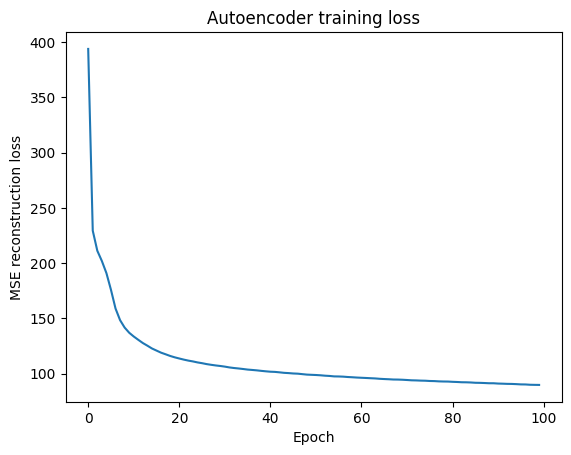

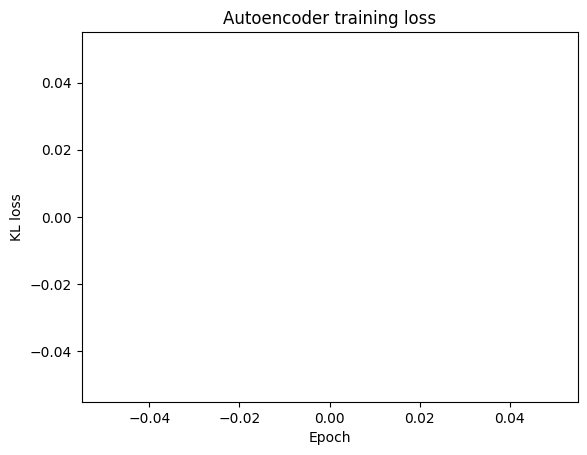

(1500, 8) (1500,)
(1500, 8) (1500,)


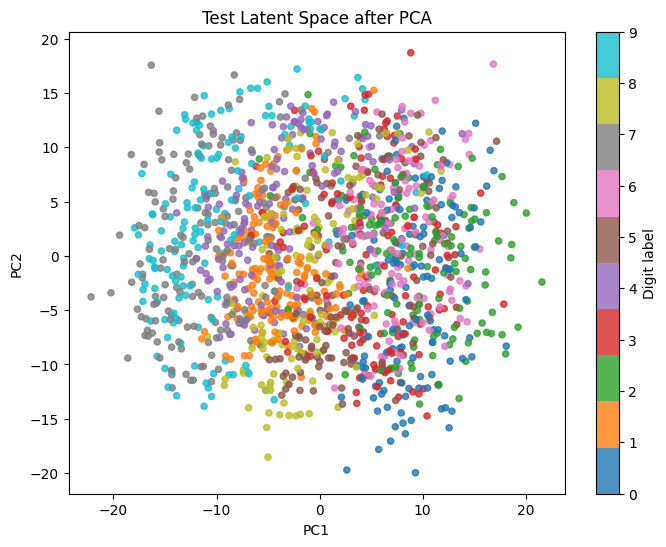

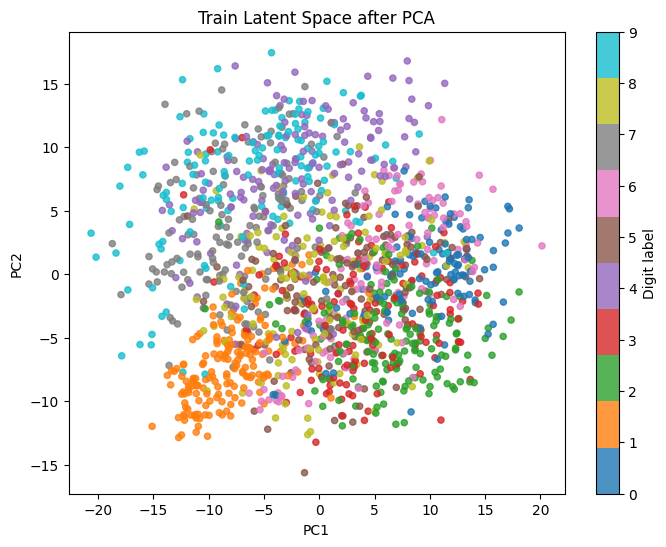

Adjusted Rand Index: 0.3601684080290978
Normalized Mutual Information: 0.4764333879920642
Adjusted Rand Index: 0.34112629655570864
Normalized Mutual Information: 0.4703533975518061


In [36]:
device = torch.device("cpu")
model = VanillaAutoEncoder(in_dim, hidden_dim, latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
name = "AE"
dps = 1500
test(device, model, optimizer, name, dps)

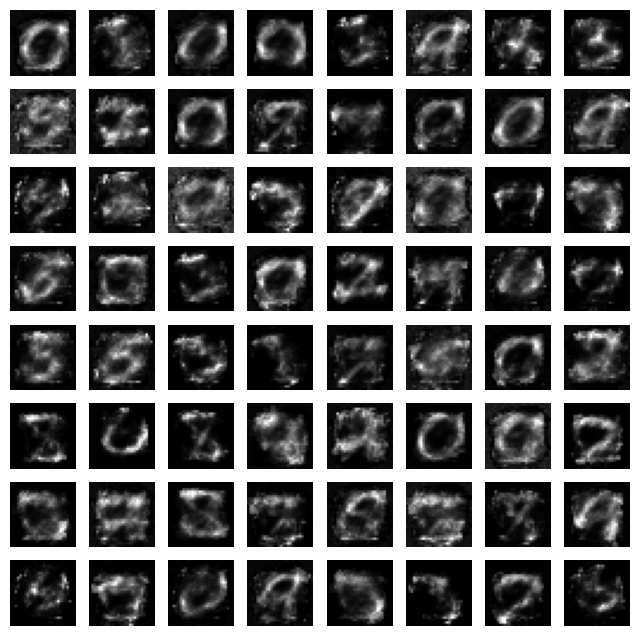

In [37]:
transform = transforms.ToTensor()
mnist_train = datasets.MNIST(
root="./data",
train=True,
download=True,
transform=transform
)

mnist_test = datasets.MNIST(
root="./data",
train=False,
download=True,
transform=transform
)

train_subset = Subset(mnist_train, range(dps))
test_subset = Subset(mnist_test, range(dps))

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)
def show_images(imgs, n=8):
    imgs = imgs.view(-1, 28, 28).cpu()

    plt.figure(figsize=(8, 8))
    for i in range(n * n):
        plt.subplot(n, n, i + 1)
        plt.imshow(imgs[i], cmap="gray")
        plt.axis("off")
    plt.show()


model.eval()

with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    samples = model.decoder(z)

show_images(samples, n=8)

100%|██████████| 15/15 [00:00<00:00, 33.47it/s]


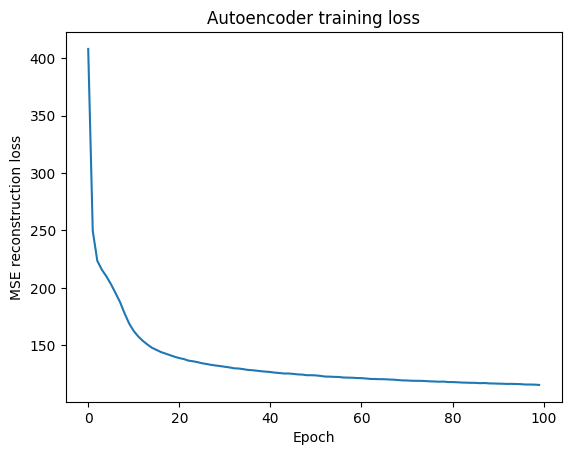

In [ ]:
device = torch.device("cpu")
model = VAE(in_dim, hidden_dim, latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
name = "VAE"
dps = 1500
test(device, model, optimizer, name, dps)


transform = transforms.ToTensor()
mnist_train = datasets.MNIST(
root="./data",
train=True,
download=True,
transform=transform
)

mnist_test = datasets.MNIST(
root="./data",
train=False,
download=True,
transform=transform
)

train_subset = Subset(mnist_train, range(dps))
test_subset = Subset(mnist_test, range(dps))

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)
def show_images(imgs, n=8):
    imgs = imgs.view(-1, 28, 28).cpu()

    plt.figure(figsize=(8, 8))
    for i in range(n * n):
        plt.subplot(n, n, i + 1)
        plt.imshow(imgs[i], cmap="gray")
        plt.axis("off")
    plt.show()


model.eval()

with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    samples = model.decoder(z)

show_images(samples, n=8)

In [ ]:
def interpolate_between_digits(model, loader, device, digit_a=1, digit_b=2, steps=10):
    model.eval()

    x_a = None
    x_b = None

    # find one example of each digit
    for x, y in loader:
        for i in range(len(y)):
            if y[i].item() == digit_a and x_a is None:
                x_a = x[i:i+1]
            if y[i].item() == digit_b and x_b is None:
                x_b = x[i:i+1]
            if x_a is not None and x_b is not None:
                break
        if x_a is not None and x_b is not None:
            break

    x_a = x_a.to(device).view(1, -1)
    x_b = x_b.to(device).view(1, -1)

    with torch.no_grad():
        if isinstance(model, VAE):
            mu_a, logvar_a = model.encode(x_a)
            mu_b, logvar_b = model.encode(x_b)

            z_a = mu_a
            z_b = mu_b
        else:
            _, z_a = model(x_a)
            _, z_b = model(x_b)

        alphas = torch.linspace(0, 1, steps).to(device)

        z_path = torch.cat([
            (1 - a) * z_a + a * z_b
            for a in alphas
        ], dim=0)

        imgs = model.decoder(z_path)

    plt.figure(figsize=(steps, 2))
    for i in range(steps):
        plt.subplot(1, steps, i + 1)
        plt.imshow(imgs[i].view(28, 28).cpu(), cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Latent interpolation: {digit_a} → {digit_b}")
    plt.show()

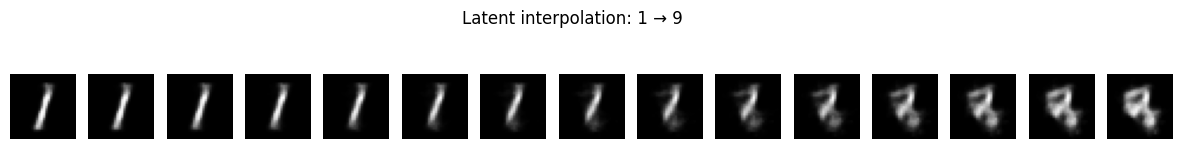

In [ ]:
interpolate_between_digits(model, test_loader, device, digit_a=1, digit_b=9, steps=15)

In [ ]:
in_dim = 64
hidden_dim = 256
latent_dim = 784

In [ ]:
class GAN(nn.Module):
        def __init__(self, in_dim, hidden_dim, latent_dim):
                super().__init__()
                self.generator = nn.Sequential(
                        nn.Linear(in_dim, hidden_dim),
                        nn.ReLU(),
                        nn.Linear(hidden_dim, latent_dim),
                )
                self.discriminator = nn.Sequential(
                        nn.Linear(latent_dim, hidden_dim),
                        nn.ReLU(),
                        nn.Linear(hidden_dim, 1),
                        nn.Sigmoid()
                )

        def generate(self, z):
                return self.generator(z)

        def discriminate(self, x):
                return self.discriminator(x)

In [ ]:
def train_gan(device, model, G_optimizer, D_optimizer, dps):
        G_losses = []
        D_losses = []

        transform = transforms.ToTensor()

        mnist_train = datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform
        )

        train_subset = Subset(mnist_train, range(dps))
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

        loss_func = nn.BCELoss()
        for epoch in range(num_epochs):
                epoch_D_loss = 0.0
                epoch_G_loss = 0.0

                for x, y in tqdm(train_loader):
                        D_optimizer.zero_grad()

                        x = x.to(device)
                        x = x.view(x.size(0), -1)
                        M = x.size(0)
                        real_labels = torch.ones(M, 1).to(device)
                        fake_labels = torch.zeros(M, 1).to(device)

                        true_inputs = model.discriminate(x)
                        lossTrue = loss_func(true_inputs, real_labels)


                        x = torch.randn(M, in_dim).to(device)
                        false_inputs = model.discriminator(model.generator(x.detach()))
                        lossFake = loss_func(false_inputs, fake_labels)
                        
                        D_loss = lossTrue + lossFake

                        D_loss.backward()
                        D_optimizer.step()

                        #______________________
                        G_optimizer.zero_grad()
                        x = torch.randn(M, in_dim).to(device)
                        false_inputs = model.discriminator(model.generator(x))
                        G_loss = loss_func(false_inputs, real_labels)

                        G_loss.backward()
                        G_optimizer.step()

                        epoch_D_loss += D_loss.item()
                        epoch_G_loss += G_loss.item()

                avg_D_loss = epoch_D_loss / len(train_loader)
                avg_G_loss = epoch_G_loss / len(train_loader)

                D_losses.append(avg_D_loss)
                G_losses.append(avg_G_loss)
                        
        return G_losses, D_losses

In [ ]:
device = torch.device("cpu")

model = GAN(in_dim, hidden_dim, latent_dim).to(device)

G_optimizer = torch.optim.Adam(model.generator.parameters(), lr=1e-3)
D_optimizer = torch.optim.Adam(model.discriminator.parameters(), lr=1e-3)



G_losses, D_losses = train_gan(
    device=device,
    model=model,
    G_optimizer=G_optimizer,
    D_optimizer=D_optimizer,
    dps=1500
)

100%|██████████| 15/15 [00:00<00:00, 38.15it/s]


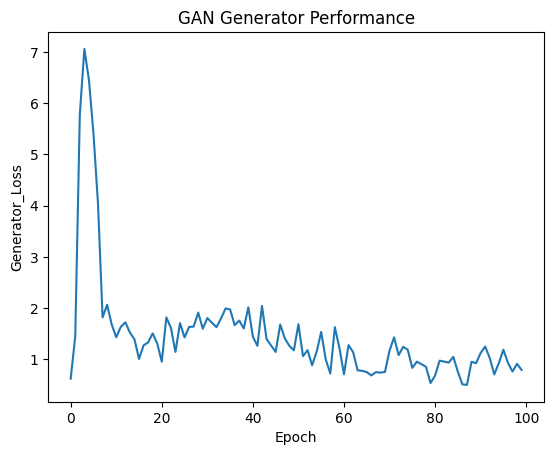

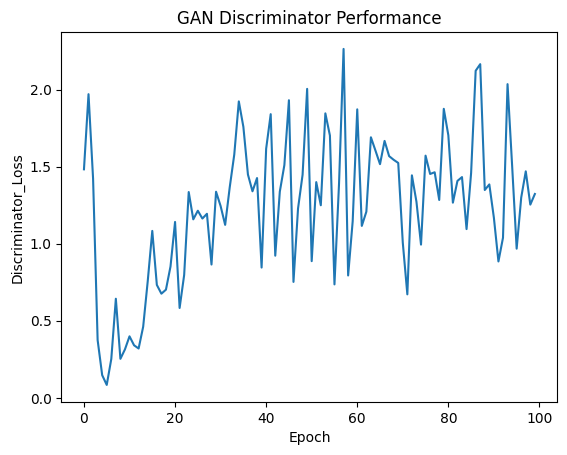

In [ ]:
plt.plot(G_losses)
plt.xlabel("Epoch")
plt.ylabel("Generator_Loss")
plt.title("GAN Generator Performance")
plt.show()

plt.plot(D_losses)
plt.xlabel("Epoch")
plt.ylabel("Discriminator_Loss")
plt.title("GAN Discriminator Performance")
plt.show()


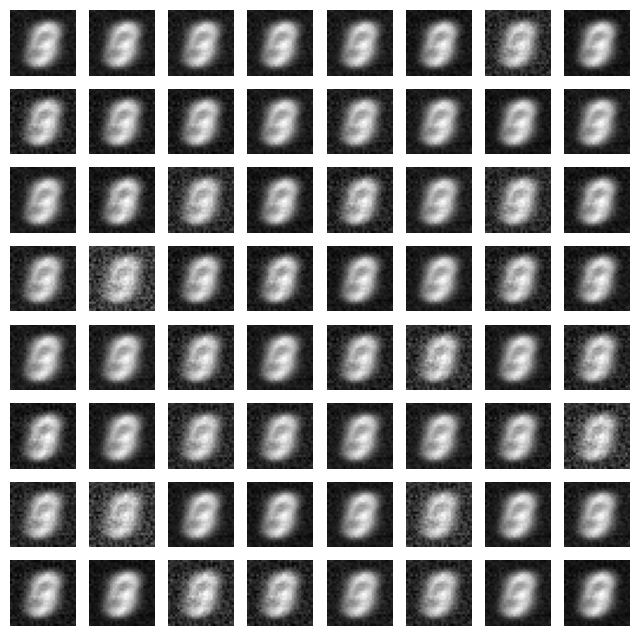

In [ ]:
model.eval()

num_images = 64

with torch.no_grad():
    z = torch.randn(num_images, 64).to(device)
    fake_images = model.generate(z)

show_images(fake_images, n=8)

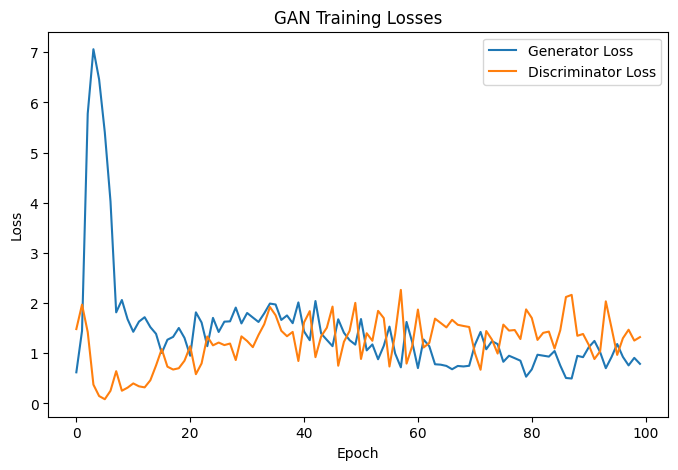

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.show()

In [ ]:
import numpy as np

g = np.array(G_losses)
d = np.array(D_losses)

corr = np.corrcoef(g, d)[0, 1]

print("Pearson correlation:", corr)

Pearson correlation: -0.5155283196579026


In [ ]:
class AAE(nn.Module):
        def __init__(self, in_dim, hidden_dim, latent_dim):
                super().__init__()
                self.encoder = nn.Sequential(
                        nn.Linear(in_dim, hidden_dim),
                        nn.ReLU(),
                        nn.Linear(hidden_dim, latent_dim),
                )
                self.decoder = nn.Sequential(
                        nn.Linear(latent_dim, hidden_dim),
                        nn.ReLU(),
                        nn.Linear(hidden_dim, in_dim),
                        nn.Sigmoid()
                )
                self.discriminator = nn.Sequential(
                        nn.Linear(latent_dim, hidden_dim),
                        nn.ReLU(),
                        nn.Linear(hidden_dim, 1),
                        nn.Sigmoid()
                )

        def encode(self, z):
                latent = self.encoder(z)
                return latent

        def decode(self,z):
                return self.decoder(z)



        def discriminate(self, x):
                return self.discriminator(x)

In [ ]:
in_dim = 784
hidden_dim = 256
latent_dim = 2
num_epochs = 300

In [ ]:
from sklearn.datasets import make_swiss_roll
import torch

def sample_ring(n, device="cpu", radius=2.0, noise=0.05):
    theta = 2 * torch.pi * torch.rand(n, 1, device=device)
    r = radius + noise * torch.randn(n, 1, device=device)

    z = torch.cat([
        r * torch.cos(theta),
        r * torch.sin(theta)
    ], dim=1)

    return z


In [ ]:
def train_aae(device, model, encoder_optimizer, decoder_optimizer,discriminator_optimizer, dps):
        
        enc_losses = []
        disc_losses = []
        recon_losses = []

        transform = transforms.ToTensor()

        mnist_train = datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform
        )

        train_subset = Subset(mnist_train, range(dps))
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

        loss_func = nn.BCELoss()
        recon_loss_func = nn.MSELoss(reduction="sum")
        for epoch in range(num_epochs):
                recon_loss = 0.0
                disc_loss = 0.0
                enc_loss = 0.0
                
                for x, y in tqdm(train_loader):
                        encoder_optimizer.zero_grad()
                        decoder_optimizer.zero_grad()
                        discriminator_optimizer.zero_grad()

                        
                        x = x.to(device)
                        x = x.view(x.size(0), -1)
                        M = x.size(0)


                        x_hat = model.decode(model.encode(x))
                        rec_loss = recon_loss_func(x_hat, x) / (15*M)
                        rec_loss.backward()
                        encoder_optimizer.step()
                        decoder_optimizer.step()
                        encoder_optimizer.zero_grad()
                        #------------------------------
                        real_labels = torch.ones(M, 1).to(device)
                        fake_labels = torch.zeros(M, 1).to(device)
                        
                        fake_latent = model.encode(x).detach()
                        lossFake = loss_func(model.discriminate(fake_latent), fake_labels)

                        z = sample_ring(x.size(0))
                        lossTrue = loss_func(model.discriminate(z), real_labels)

                        loss_D = lossTrue + lossFake
                        loss_D.backward()
                        discriminator_optimizer.step()
                        #------------------------------
                        fake_latent = model.encode(x)
                        lossReal = loss_func(model.discriminate(fake_latent), real_labels)
                        lossReal.backward()
                        encoder_optimizer.step()

                        recon_loss += rec_loss.item()
                        disc_loss += loss_D.item()
                        enc_loss += lossReal.item()

                avg_recon_loss = recon_loss / len(train_loader)
                avg_disc_loss = disc_loss / len(train_loader)
                avg_enc_loss = enc_loss / len(train_loader)

                recon_losses.append(avg_recon_loss)
                disc_losses.append(avg_disc_loss)
                enc_losses.append(avg_enc_loss)
                        
        return enc_losses, disc_losses, recon_losses

In [ ]:
device = torch.device("cpu")

model = AAE(in_dim, hidden_dim, latent_dim).to(device)

encoder_optimizer = torch.optim.Adam(model.encoder.parameters(), lr=1e-3)
decoder_optimizer = torch.optim.Adam(model.decoder.parameters(), lr=1e-3)
discriminator_optimizer = torch.optim.Adam(model.discriminator.parameters(), lr=1e-3)


enc_losses, disc_losses, recon_losses = train_aae(
    device=device,
    model=model,
    encoder_optimizer=encoder_optimizer,
    decoder_optimizer=decoder_optimizer,
    discriminator_optimizer = discriminator_optimizer,
    dps=1500
)

100%|██████████| 15/15 [00:00<00:00, 37.43it/s]


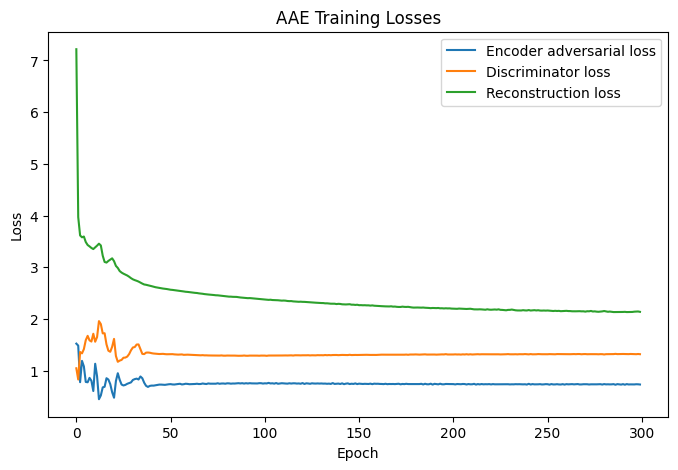

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(enc_losses, label="Encoder adversarial loss")
plt.plot(disc_losses, label="Discriminator loss")
plt.plot(recon_losses, label="Reconstruction loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("AAE Training Losses")
plt.legend()
plt.show()

In [ ]:
def extract_latents(model, loader, device):
    model.eval()

    all_z = []
    all_y = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            x = x.view(x.size(0), -1)

            z = model.encode(x)

            all_z.append(z.cpu())
            all_y.append(y)

    all_z = torch.cat(all_z, dim=0).numpy()
    all_y = torch.cat(all_y, dim=0).numpy()

    return all_z, all_y

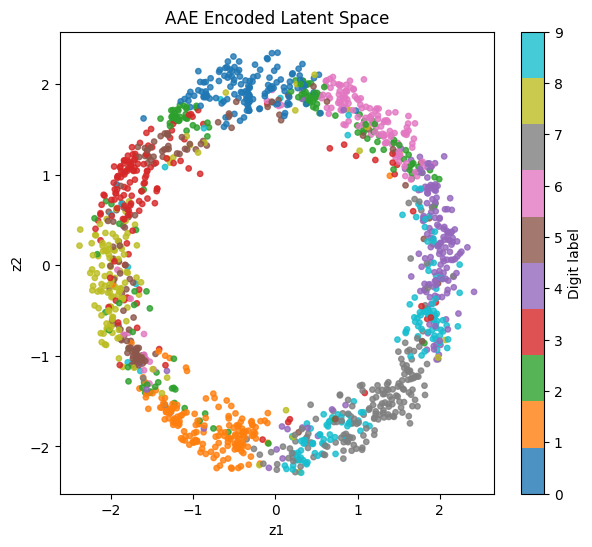

In [ ]:
z_encoded, y_encoded = extract_latents(model, train_loader, device)

plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    z_encoded[:, 0],
    z_encoded[:, 1],
    c=y_encoded,
    cmap="tab10",
    s=15,
    alpha=0.8
)

plt.colorbar(scatter, label="Digit label")
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("AAE Encoded Latent Space")
plt.show()

In [ ]:
def show_reconstructions(model, loader, device, n=8):
    model.eval()

    x, y = next(iter(loader))
    x = x.to(device)
    x_flat = x.view(x.size(0), -1)

    with torch.no_grad():
        x_hat = model.decode(model.encode(x_flat))

    x = x[:n].cpu()
    x_hat = x_hat[:n].view(-1, 1, 28, 28).cpu()

    plt.figure(figsize=(n, 2))

    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(x[i].squeeze(), cmap="gray")
        plt.axis("off")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(x_hat[i].squeeze(), cmap="gray")
        plt.axis("off")

    plt.suptitle("Top: original, Bottom: reconstruction")
    plt.tight_layout()
    plt.show()

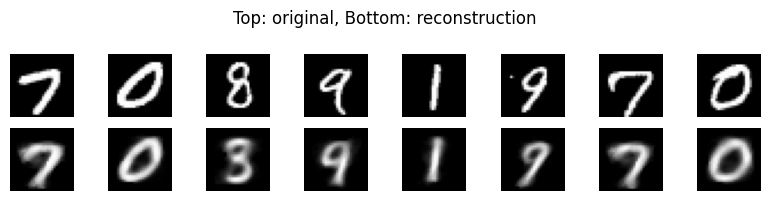

In [ ]:
show_reconstructions(model, train_loader, device, n=8)